In [1]:
%pip install openexr-numpy
%pip install opencv-python
%matplotlib inline


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [19]:
import math

import cv2
import openexr_numpy
import numpy as np

import matplotlib.pyplot as plt

from PIL import Image
from IPython.display import display

In [3]:
def normalize_to_uint8(data: np.ndarray) -> np.ndarray:
    return (np.iinfo(np.uint8).max * ((data - np.min(data)) / np.ptp(data))).astype(np.uint8)

In [24]:
img_depth = openexr_numpy.imread("assets/Depth0001.exr", "V")
# img_rgb = openexr_numpy.imread("assets/Image0001.exr", "RGB")
img_gray = cv2.imread("assets/Image0001.tif", cv2.IMREAD_GRAYSCALE)
img_normals = openexr_numpy.imread("assets/Normals_UnitSphere_n10.exr", "XYZ")
# img_normals = openexr_numpy.imread("assets/Normals_Cube_30deg.exr", "XYZ")

5.9987187 100.00248
5.9987187 8.498718


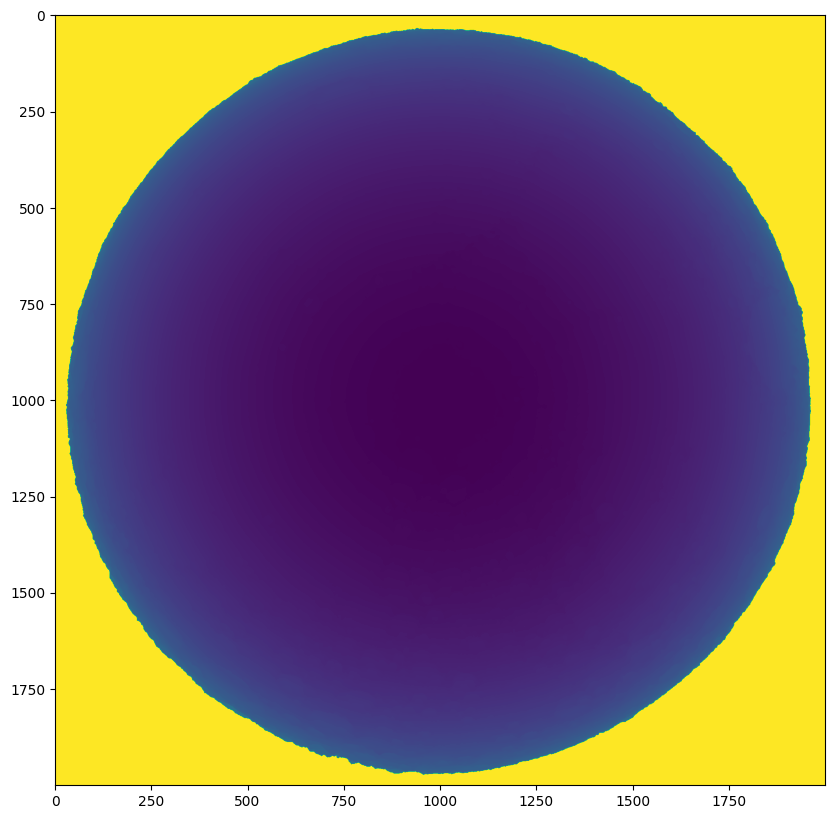

In [25]:
plt.rcParams["figure.figsize"] = (10, 10)

print(np.min(img_depth), np.max(img_depth))

img_clipped = np.clip(img_depth, np.min(img_depth), np.min(img_depth) + 2.5)
print(np.min(img_clipped), np.max(img_clipped))
plt.imshow(img_clipped)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


[-158.642578125, -84.9462890625, -0.0037014484405517582]
[158.642578125, -84.9462890625, -0.0037014484405517582]


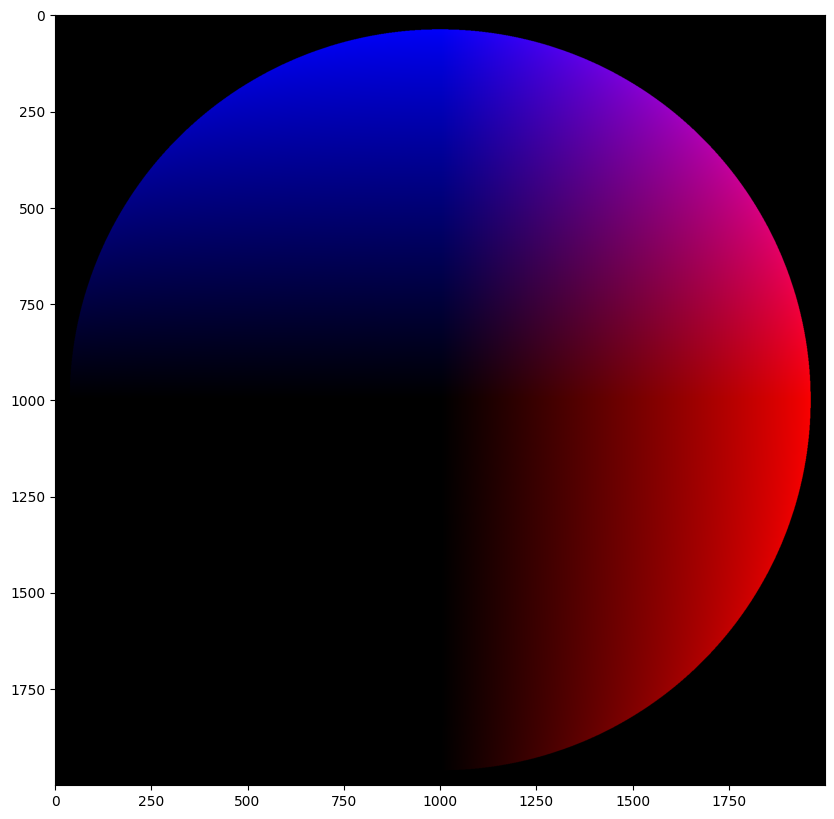

In [47]:
plt.imshow(img_normals)

left = img_normals[1000, 100]
right = img_normals[1000, 2000-100]

print([math.degrees(c*math.pi) for c in left])
print([math.degrees(c*math.pi) for c in right])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


-0.9995117
0.98876953
---
-0.99970703125
0.9999023437500001
---
[-137.197265625, -116.3671875, -0.0038516521453857418]
[137.197265625, -116.3671875, -0.0038516521453857418]
[168.802734375, -116.3671875, -72.0038516521454]
[83.19726562499999, -116.3671875, -72.0038516521454]


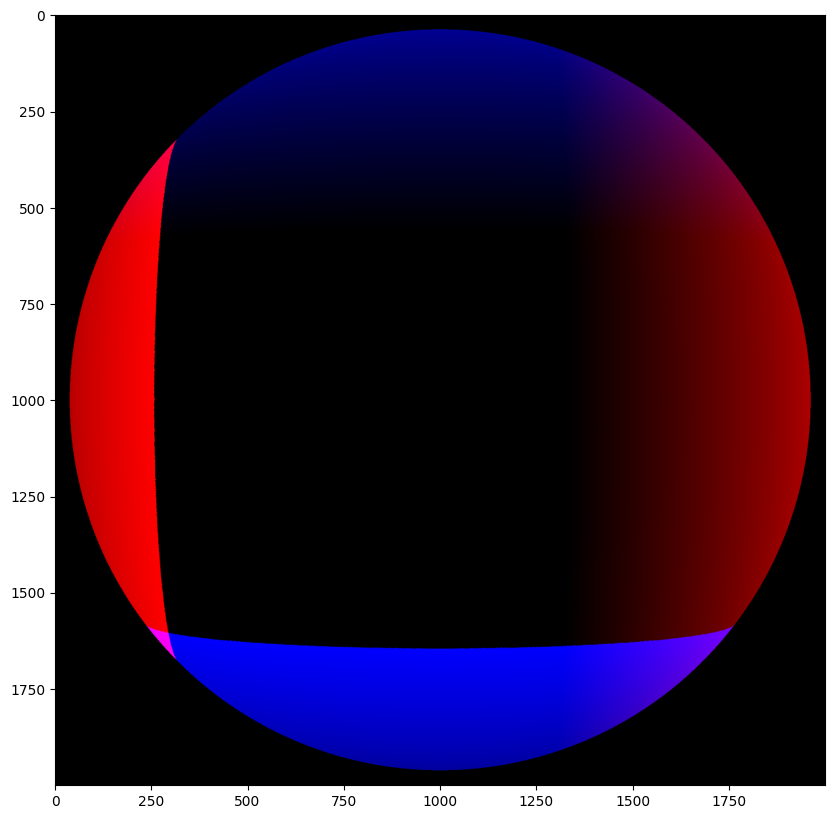

In [48]:
img_normals_shifted = img_normals + [-0.3, 0.0, -0.4]
img_normals_shifted += 1
img_normals_shifted = np.mod(img_normals_shifted, 2)
img_normals_shifted -= 1

print(np.min(img_normals))
print(np.max(img_normals))
print("---")
print(np.min(img_normals_shifted))
print(np.max(img_normals_shifted))
print("---")

plt.imshow(img_normals_shifted)



print([math.degrees(c*math.pi) for c in img_normals[1000, 200]])
print([math.degrees(c*math.pi) for c in img_normals[1000, 2000-200]])

print([math.degrees(c*math.pi) for c in img_normals_shifted[1000, 200]])
print([math.degrees(c*math.pi) for c in img_normals_shifted[1000, 2000-200]])

In [7]:
def get_slope(
    data: np.ndarray, sampling_step: int
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Computes angle (in rad) and magnitude of the given 2D array of values
    """
    test_slice = data[::sampling_step, ::sampling_step]
    r, c = np.shape(data)
    Y, X = np.mgrid[0:r:sampling_step, 0:c:sampling_step]
    dY, dX = np.gradient(test_slice)  # order! Y X

    angles = np.arctan2(dY, dX)
    magnitude = np.hypot(dY, dX)

    if sampling_step > 1:
        angles = cv2.resize(angles, data.shape)
        magnitude = cv2.resize(magnitude, data.shape)

    return (X, Y, dX, dY, angles, magnitude)


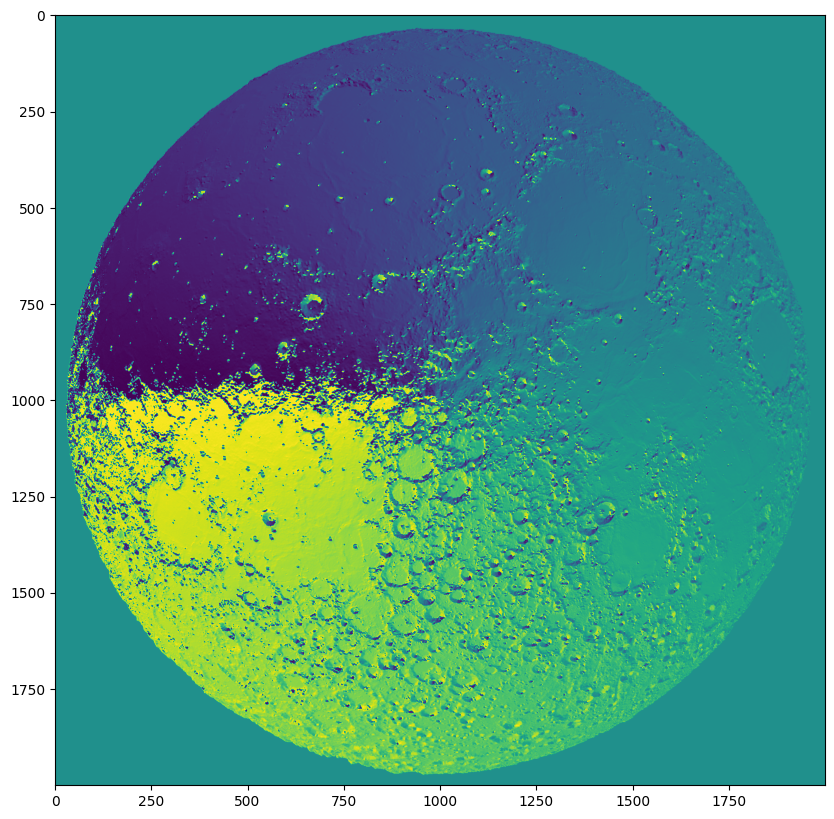

In [8]:
_, _, dX, dY, angles, magnitude = get_slope(img_depth, 1)
plt.imshow(angles)

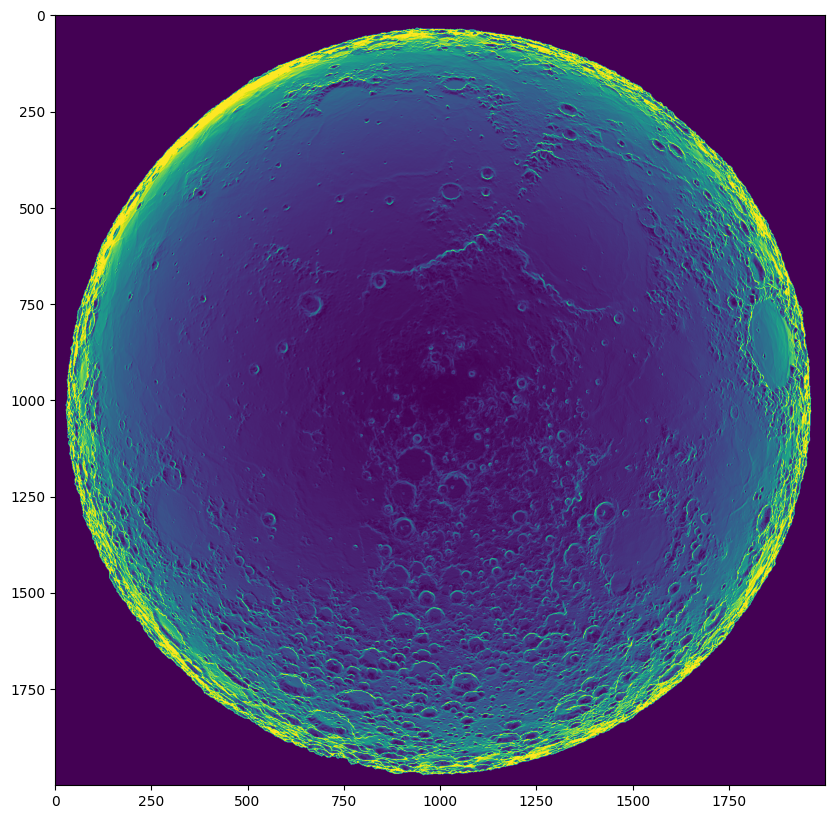

In [9]:
plt.imshow(np.clip(magnitude, 0, 0.005))

In [10]:
# mapping_distance = np.mean(np.clip(img_rgb, 0, 1), axis=2) # normalize_to_uint8(img_rgb)
mapping_distance = np.mean(img_rgb, axis=2)
print(mapping_distance.shape)
plt.imshow(normalize_to_uint8(mapping_distance))
# plt.imshow(img_rgb)
# print(np.min(img_rgb), np.max(img_rgb))

NameError: name 'img_rgb' is not defined

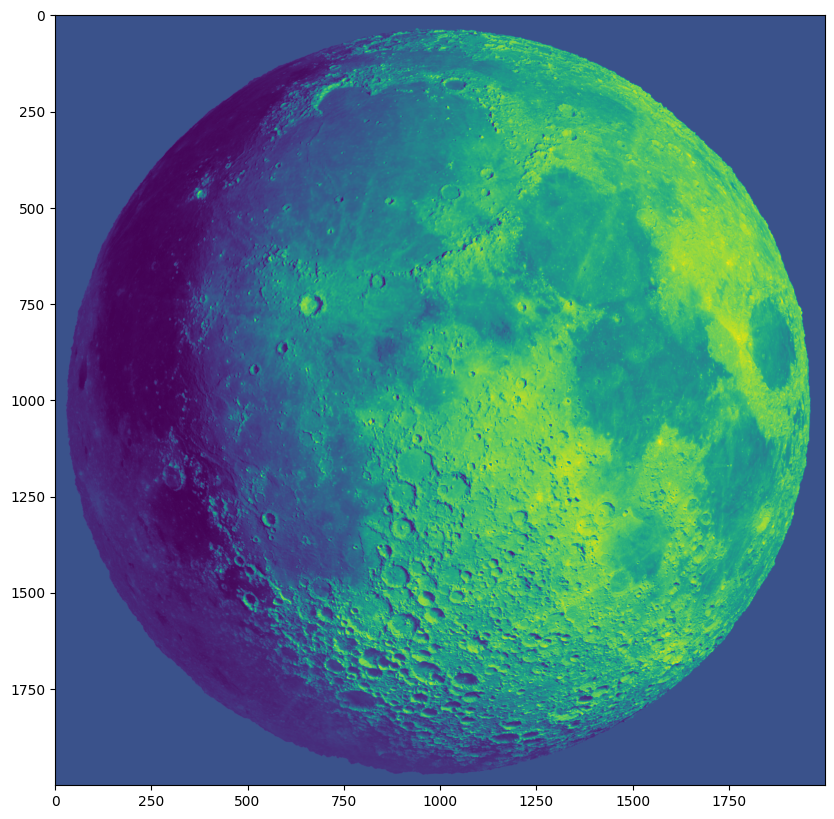

In [11]:
mapping_distance = img_gray
plt.imshow(mapping_distance)